# Expanding Safe Parking for Urban Vehicle Residents Analysis

*UP213 Urban Data Science SQ25*

**Group Members:** Simon Han, Tomohiro Ujikawa

## Objective
Our project aims to address vehicle living in LA by identifying where vehicle residents are clustered and where there could be safe and sanctioned places to park at night, particularly in areas with excess capacity through city parking garages.

## Background
Vehicle residency is rising among working-class individuals and families as housing costs outpace wages in Los Angeles. Safe parking programs offer legal overnight parking for vehicle residents along with access to restrooms and supportive services. However, the transient and discreet nature of many vehicle residents poses operational challenges for these programs. In addition, long waitlists and limited capacity at individual sites often discourage those with urgent needs from enrolling. To address these gaps, it is essential to better align areas of high need with high-capacity parking facilities that can operate with minimal staffing and oversight.

## Key Questions
- Where are the vehicle homeless clusters in Los Angeles?
- Where are parking facilities with high capacity in areas with high need?

## Dataset
- **LAHSA Homeless Count**: vehicle dwelling counts by tract
- **ACS**: poverty, rent burden, vehicle ownership, housing overcrowding, etc.
- **TIGER/Line**: Census tract boundaries for spatial analysis
- **SCAG 2019 Regional Land Use Type**: public parking facilities (LU19 code 1247)
- **Public Facilities Data**: Locations of essential services (hospitals, schools, transportation hubs, and food pantries)

## Methods
- **Spatial Joins** to overlay homelessness data with garage locations
- **Random Forests** to predict vehicle homelessness based on demographic and economic factors
- **Cluster Analysis** to identify different typologies of vehicle homelessness
- **Visualization** of results through various maps and charts

# Data Preparation

Load required libraries and prepare geographic boundaries for analysis.

In [1]:
import contextily as ctx
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import seaborn as sns
import warnings
import zipfile

from matplotlib.colors import LinearSegmentedColormap
from matplotlib.colors import ListedColormap
from sklearn.cluster import KMeans
from sklearn import preprocessing
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import PartialDependenceDisplay
from sklearn.model_selection import train_test_split
from sklearn import metrics, preprocessing

In [2]:
# Load Tiger/Line census tract boundaries
drop_geoids = ['06037990100', '06037990200', '06037990300']  # Catalina Island tracts

for year in range(2019, 2025):
    path = f"Data/tl_shp_library/tl_{year}_06_tract.zip"
    tracts = gpd.read_file(path)
    la_tracts = tracts[(tracts["COUNTYFP"] == "037") & (tracts["STATEFP"] == "06")]
    la_tracts = la_tracts.set_index('GEOID')
    la_tracts = la_tracts.drop(index=drop_geoids, errors='ignore')
    
    var_name = f"tracts{str(year)[-2:]}"
    globals()[var_name] = la_tracts

<div class="alert alert-block alert-info">
<h3>Key Takeaways</h3>
<ul>
<li>Census tract boundaries loaded for 2019-2024</li>
<li>Catalina Island tract GEOIDs removed</li>
</ul>
</div>

# Land Use Analysis

Analyze land use patterns to understand residential concentration and parking availability.

In [3]:
# Load SCAG land use data
if os.path.exists("Data/landuse_processed.gpkg"):
    luGdf = gpd.read_file("Data/landuse_processed.gpkg")
else:
    # Process land use data from raw file
    with zipfile.ZipFile("Data/landuse.gpkg.zip", 'r') as zip_ref:
        zip_ref.extractall("Data/")
    luGdf = gpd.read_file("Data/landuse.gpkg")
    
    # Select relevant columns
    selected_cols = ['ACRES', 'GEOID20', 'DEN_AVG', 'ZN19_SCAG', 'LU19', 'geometry']
    luGdf = luGdf[selected_cols]
    
    # Create major land use categories
    luGdf['LU19'] = pd.to_numeric(luGdf['LU19'], errors='coerce')
    lu19_major_categories = {
        1100: "Residential",
        1200: "Commercial and Services",
        1300: "Industrial",
        1400: "Transportation, Communications, and Utilities",
        1500: "Public Facilities",
        1600: "Open Space and Recreation",
        1700: "Vacant",
        1800: "Water",
        1900: "Agriculture",
        8888: "Undevelopable or Protected Land",
        9999: "LandUnknown"
    }
    
    luGdf['LU19_major_code'] = (luGdf['LU19'] // 100) * 100
    luGdf.loc[luGdf['LU19'] == 8888, 'LU19_major_code'] = 8888
    luGdf.loc[luGdf['LU19'] == 9999, 'LU19_major_code'] = 9999
    luGdf['LU19_major_label'] = luGdf['LU19_major_code'].map(lu19_major_categories)
    
    # Save processed land use data
    luGdf.to_file("Data/landuse_processed.gpkg", driver="GPKG")

In [4]:
# Calculate residential land use proportion by tract
luGdf['GEOID'] = luGdf['GEOID20'].str[:11]
luGdf_proj = luGdf.to_crs(epsg=3497)
luGdf_proj['area_m2'] = luGdf_proj.geometry.area

tract_lu = luGdf_proj.groupby(['GEOID', 'LU19_major_label'])['area_m2'].sum().reset_index()
tract_total = tract_lu.groupby('GEOID')['area_m2'].sum().reset_index(name='total_area_m2')
tract_lu = tract_lu.merge(tract_total, on='GEOID')
tract_lu['percent'] = tract_lu['area_m2'] / tract_lu['total_area_m2'] * 100

tract_lu_wide = tract_lu.pivot(index='GEOID', columns='LU19_major_label', values='percent').reset_index()
tract_lu_wide.columns = ['GEOID'] + [f"pct_{col.lower().replace(' ', '_').replace(',', '').replace('&', 'and')}" for col in tract_lu_wide.columns[1:]]
tracts23 = tracts23.merge(tract_lu_wide, on='GEOID', how='left')

landuse_cols = [
    'pct_residential',
    'pct_commercial_and_services',
    'pct_industrial',
    'pct_transportation_communications_and_utilities',
    'pct_public_facilities',
    'pct_open_space_and_recreation',
    'pct_vacant',
    'pct_water',
    'pct_agriculture',
    'pct_undevelopable_or_protected_land',
    'pct_landunknown'
]

tracts23[landuse_cols] = tracts23[landuse_cols].fillna(0)

<div class="alert alert-block alert-info">
<h3>Key Takeaways</h3>
<ul>
<li>Land use categorized into 11 major types from SCAG 2019 data</li>
<li>Residential land use proportion calculated for each census tract</li>
</ul>
</div>

# Amenities Analysis

Count public facilities and parking within buffer zones around census tracts.

In [5]:
# Create 2000m buffers around tracts
tracts23_buffer = tracts23.to_crs(epsg=3497).copy()
tracts23_buffer["geometry"] = tracts23_buffer.buffer(2000)

# Load public facilities data
facilities = {
    'ArtsRecreation': gpd.read_file("data/public_facilities/ArtsRecreation.gpkg").to_crs(epsg=3497),
    'Education': gpd.read_file("data/public_facilities/Education.gpkg").to_crs(epsg=3497),
    'Hospitals': gpd.read_file("data/public_facilities/Hospitals.gpkg").to_crs(epsg=3497),
    'MunicipalServices': gpd.read_file("data/public_facilities/MunicipalServices.gpkg").to_crs(epsg=3497),
    'PhysicalFeatures': gpd.read_file("data/public_facilities/PhysicalFeatures.gpkg").to_crs(epsg=3497),
    'PublicSafety': gpd.read_file("data/public_facilities/PublicSafety.gpkg").to_crs(epsg=3497),
    'Transportation': gpd.read_file("data/public_facilities/Transportation.gpkg").to_crs(epsg=3497)
}

# Remove jails from public safety facilities
facilities['PublicSafety'] = facilities['PublicSafety'][
    ~facilities['PublicSafety']["cat2"].isin(["Jails and Prisons", "Probation Camps and Juvenile Halls"])
].reset_index(drop=True)

# Load food pantries
pantry_df = pd.read_csv('data/Food_Resources_in_California.csv')
pantry_df = pantry_df[pantry_df.County == 'Los Angeles']
facilities['Pantry'] = gpd.GeoDataFrame(
    pantry_df, 
    geometry=gpd.points_from_xy(pantry_df.Longitude, pantry_df.Latitude, crs='EPSG:4326')
).to_crs(epsg=3497)

# Extract parking lots from land use data
parking = luGdf[luGdf['LU19'] == 1247].to_crs(epsg=3497).copy()
parking = parking.set_index('GEOID')
parking['geometry'] = parking.centroid

/opt/anaconda3/envs/uds/lib/python3.12/site-packages/pyogrio/raw.py:198: RuntimeWarning: This version of GeoPackage user_version=0x000028A0 (10400, v1.4.0) on 'data/public_facilities/ArtsRecreation.gpkg' may only be partially supported
  return ogr_read(
/opt/anaconda3/envs/uds/lib/python3.12/site-packages/pyogrio/raw.py:198: RuntimeWarning: This version of GeoPackage user_version=0x000028A0 (10400, v1.4.0) on 'data/public_facilities/Education.gpkg' may only be partially supported
  return ogr_read(
/opt/anaconda3/envs/uds/lib/python3.12/site-packages/pyogrio/raw.py:198: RuntimeWarning: Non-conformant content for record 1 in column last_update, 2025-03-10T00:00:00.0Z, successfully parsed
  return ogr_read(
/opt/anaconda3/envs/uds/lib/python3.12/site-packages/pyogrio/raw.py:198: RuntimeWarning: This version of GeoPackage user_version=0x000028A0 (10400, v1.4.0) on 'data/public_facilities/Hospitals.gpkg' may only be partially supported
  return ogr_read(
/opt/anaconda3/envs/uds/lib/python

In [6]:
# Count facilities within tract buffers
def count_facilities_within_tracts(tracts_gdf, points_gdf, buffer_gdf_name):
    tmp = gpd.sjoin(tracts_gdf, points_gdf, predicate='intersects')
    counts = tmp.groupby('GEOID').size()
    counts.name = f'n_{buffer_gdf_name}'
    tracts_gdf = tracts_gdf.join(counts)
    tracts_gdf[f'n_{buffer_gdf_name}'] = tracts_gdf[f'n_{buffer_gdf_name}'].fillna(0)
    return tracts_gdf

# Count all facility types
for facility_name, facility_gdf in facilities.items():
    tracts23_buffer = count_facilities_within_tracts(tracts23_buffer, facility_gdf, facility_name)

# Count parking facilities
tracts23_buffer = tracts23_buffer.reset_index()
tmpgdf_ms = gpd.sjoin(tracts23_buffer, parking, predicate='intersects')
parking_counts = tmpgdf_ms.groupby('GEOID_left').size()
parking_counts.name = 'n_Parking'
tracts23_buffer = tracts23_buffer.set_index('GEOID').join(parking_counts).reset_index()
tracts23_buffer['n_Parking'] = tracts23_buffer['n_Parking'].fillna(0).astype(int)

# Transfer amenity counts back to tracts23
tracts23_geom = tracts23.reset_index().to_crs(epsg=3497)[['GEOID', 'geometry']]
tracts23 = tracts23_buffer.drop(columns='geometry').merge(tracts23_geom, on='GEOID')
tracts23 = gpd.GeoDataFrame(tracts23, geometry='geometry', crs='EPSG:3497')

<div class="alert alert-block alert-info">
<h3>Key Takeaways</h3>
<ul>
<li>Created 2km buffers around census tracts for amenity analysis</li>
<li>Counted 9 types of facilities including parking, education, healthcare, and food pantries</li>
</ul>
</div>

# Homelessness Data Processing

Process LAHSA street count data to identify vehicle homelessness patterns.

In [7]:
# Process LAHSA data for years 2022-2024
representative_cols = ['year', 'lacity', 'spa', 'sd', 'cd', 'ca_ssd', 'ca_sad', 'us_cd']
years = [22, 23, 24]

for year in years:
    hc = pd.read_csv(f"Data/LAHSA/streetcount{year}_original.csv")
    hc.columns = hc.columns.str.lower()
    hc['tract_split_base'] = hc['tract_split'].astype(str).str.extract(r'(\d{6})')
    
    numeric_cols = hc.select_dtypes(include='number').columns.tolist()
    sum_cols = [col for col in numeric_cols if col not in representative_cols]
    
    hc_agg = hc.groupby('tract_split_base').agg(
        {**{col: 'first' for col in representative_cols},
         **{col: 'sum' for col in sum_cols}}
    ).reset_index()
    
    hc_agg['GEOID'] = '06037' + hc_agg['tract_split_base']
    hc_agg.to_csv(f"Data/LAHSA/streetcount{year}.csv", index=False)

# Load all LAHSA data
hc20 = pd.read_csv('Data/LAHSA/streetcount20.csv', dtype={'tract': str})
hc20['GEOID'] = '06037' + hc20['tract']
hc20 = hc20.set_index('GEOID')

for year in [22, 23, 24]:
    df = pd.read_csv(f"Data/LAHSA/streetcount{year}.csv", dtype={'GEOID': str})
    df = df.set_index('GEOID')
    globals()[f"hc{year}"] = df

# Create aggregated variables
hc22['totencamp'] = 0
for year in [20, 22, 23, 24]:
    df = globals()[f"hc{year}"]
    df.columns = df.columns.str.lower()
    df['total_vehicle'] = df[['totcars', 'totvans', 'totcampers']].fillna(0).sum(axis=1)
    df['total_unsheltered'] = df['total_vehicle'] + df[['tottents', 'totencamp']].fillna(0).sum(axis=1)
    df['non_vehicle_unsheltered'] = df[['tottents', 'totencamp']].fillna(0).sum(axis=1)
    globals()[f"hc{year}"] = df

<div class="alert alert-block alert-info">
<h3>Key Takeaways</h3>
<ul>
<li>Aggregated split census tracts in LAHSA data for 2020-2024</li>
<li>Created total vehicle homelessness variable combining cars, vans, and campers</li>
</ul>
</div>

# American Community Survey Data

Load and process ACS variables to identify socioeconomic predictors.

In [8]:
# Load ACS data
base_path = "Data/ACS"
acs20 = pd.read_csv(os.path.join(base_path, "acs20.csv"), dtype={"GEOID": str})
acs22 = pd.read_csv(os.path.join(base_path, "acs22.csv"), dtype={"GEOID": str})
acs23 = pd.read_csv(os.path.join(base_path, "acs23.csv"), dtype={"GEOID": str})

# Calculate tract areas for density metrics
tracts23 = tracts23.to_crs(epsg=3497)
tracts23["area_km2"] = tracts23.geometry.area / 1e6
tracts23_geom = tracts23[["GEOID", "area_km2", "geometry"]].copy()
tracts23_geom.head()

,GEOID,area_km2,geometry
0,06037204920,0.909927,"POLYGON ((1981264.851 557662.754, 1981265.608 ..."
1,06037205110,0.286878,"POLYGON ((1979714.992 558400.997, 1979732.609 ..."
2,06037320101,0.680435,"POLYGON ((1959603.924 588730.095, 1959743.112 ..."
3,06037205120,1.466139,"POLYGON ((1979658.894 557766.671, 1979663.062 ..."
4,06037206010,1.438784,"POLYGON ((1977915.558 562949.765, 1978029.909 ..."


In [9]:
# Process ACS data to create analytical variables
def process_acs(df, tracts23_geom):
    # Rename key variables
    df = df.rename(columns={
        "B25077_001E": "median_home_value", 
        "B25064_001E": "median_gross_rent",
        "B25088_001E": "median_owner_costs_mortgage", 
        "B19083_001E": "gini",
        "B25001_001E": "n_total_units"
    })

    # Renter cost burden
    rent_burden_cols = ["B25070_004E", "B25070_005E", "B25070_006E", "B25070_007E"]
    rent_burden_names = ["pct_rent_30_34", "pct_rent_35_39", "pct_rent_40_49", "pct_rent_50plus"]
    for col, name in zip(rent_burden_cols, rent_burden_names):
        df[name] = np.where(df["B25070_001E"] > 0, df[col] / df["B25070_001E"] * 100, np.nan)

    # Owner cost burden
    owner_burden_cols = ["B25091_005E", "B25091_006E", "B25091_007E", "B25091_008E"]
    owner_burden_names = ["pct_owner_cost_30_34", "pct_owner_cost_35_39", "pct_owner_cost_40_49", "pct_owner_cost_50plus"]
    for col, name in zip(owner_burden_cols, owner_burden_names):
        df[name] = np.where(df["B25091_001E"] > 0, df[col] / df["B25091_001E"] * 100, np.nan)

    # Other percentages
    df["unemployment_rate"] = np.where(df["B23025_003E"] > 0, df["B23025_005E"] / df["B23025_003E"] * 100, np.nan)
    df["poverty_rate"] = np.where(df["B17001_001E"] > 0, df["B17001_002E"] / df["B17001_001E"] * 100, np.nan)
    df["public_assistance_rate"] = np.where(df["B19057_001E"] > 0, df["B19057_002E"] / df["B19057_001E"] * 100, np.nan)
    df["hud_rate"] = np.where(df["B25022_001E"] > 0, df["B25022_002E"] / df["B25022_001E"] * 100, np.nan)
    df["oldhouses_rate"] = np.where(df["B25034_001E"] > 0, df["B25034_002E"] / df["B25034_001E"] * 100, np.nan)
    df["hispanic_rate"] = np.where(df["B03003_001E"] > 0, df["B03003_003E"] / df["B03003_001E"] * 100, np.nan)
    df["imigration_rate"] = np.where(df["B07001_001E"] > 0, df["B07001_017E"] / df["B07001_001E"] * 100, np.nan)
    df["1phouseholds_rate"] = np.where(df["B11001_001E"] > 0, df["B11001_003E"] / df["B11001_001E"] * 100, np.nan)

    # Age groups
    age_65plus_cols = ["B01001_020E", "B01001_021E", "B01001_022E", "B01001_023E", "B01001_024E", "B01001_025E",
                       "B01001_044E", "B01001_045E", "B01001_046E", "B01001_047E", "B01001_048E", "B01001_049E"]
    age_under18_cols = ["B01001_003E", "B01001_004E", "B01001_005E", "B01001_006E",
                        "B01001_027E", "B01001_028E", "B01001_029E", "B01001_030E"]
    
    df["n_age_65plus"] = df[age_65plus_cols].astype(float).sum(axis=1)
    df["n_age_under18"] = df[age_under18_cols].astype(float).sum(axis=1)
    df["over65_rate"] = np.where(df["B01001_001E"] > 0, df["n_age_65plus"] / df["B01001_001E"] * 100, np.nan)
    df["under18_rate"] = np.where(df["B01001_001E"] > 0, df["n_age_under18"] / df["B01001_001E"] * 100, np.nan)

    # Overcrowding
    df["n_overcrowded_units"] = df[["B25014_003E", "B25014_004E"]].astype(float).sum(axis=1)
    df["overcrowded_rate"] = np.where(df["B25014_001E"] > 0, df["n_overcrowded_units"] / df["B25014_001E"] * 100, np.nan)

    # Merge with spatial data
    df = df.merge(tracts23, on="GEOID", how="left")
    df["housing_density"] = np.where(df["area_km2"] > 0, df["n_total_units"] / df["area_km2"], np.nan)

    return gpd.GeoDataFrame(df, geometry="geometry", crs=tracts23_geom.crs).to_crs(epsg=4326)

# Process all years
acs20 = process_acs(acs20, tracts23_geom)
acs22 = process_acs(acs22, tracts23_geom)
acs23 = process_acs(acs23, tracts23_geom)

# Clean negative values
for df in [acs20, acs22, acs23]:
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    df[numeric_cols] = df[numeric_cols].applymap(lambda x: np.nan if x < 0 else x)

/var/folders/lx/_3z8wwyx3ds15_0k28hby_h80000gn/T/ipykernel_32851/1974795666.py:63: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df[numeric_cols] = df[numeric_cols].applymap(lambda x: np.nan if x < 0 else x)
/var/folders/lx/_3z8wwyx3ds15_0k28hby_h80000gn/T/ipykernel_32851/1974795666.py:63: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df[numeric_cols] = df[numeric_cols].applymap(lambda x: np.nan if x < 0 else x)
/var/folders/lx/_3z8wwyx3ds15_0k28hby_h80000gn/T/ipykernel_32851/1974795666.py:63: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df[numeric_cols] = df[numeric_cols].applymap(lambda x: np.nan if x < 0 else x)


<div class="alert alert-block alert-info">
<h3>Key Takeaways</h3>
<ul>
<li>Processed 50+ ACS variables including housing costs, poverty, and demographics</li>
<li>Created derived metrics like overcrowding rate and housing density</li>
</ul>
</div>

# Data Integration

Join all datasets for comprehensive analysis.

In [10]:
# Join ACS and LAHSA data by year
joined20 = acs20.join(hc20, on="GEOID", how="left", rsuffix="_hc")
joined22 = acs22.join(hc22, on="GEOID", how="left", rsuffix="_hc")
joined23 = acs23.join(hc23, on="GEOID", how="left", rsuffix="_hc")

# Add year indicators
joined20["year"] = 2020
joined22["year"] = 2022
joined23["year"] = 2023

# Ensure GEOID columns are strings before concatenation
for df in [joined20, joined22, joined23, tracts23]:
    df['GEOID'] = df['GEOID'].astype(str)

# Combine all years
joined_all = pd.concat([joined20, joined22, joined23], ignore_index=False)

# Ensure it's a GeoDataFrame and set CRS
joined_all = gpd.GeoDataFrame(joined_all, geometry="geometry", crs=tracts23.crs)
joined_all = joined_all.to_crs(epsg=3497)

# Export
joined_all.to_file("Data/joined_all.gpkg", layer="joined_all", driver="GPKG")
joined_all.to_csv("Data/joined_all.csv", index=False)


<div class="alert alert-block alert-info">
<h3>Key Takeaways</h3>
<ul>
<li>Integrated LAHSA, ACS, and amenity data across 3 years</li>
<li>Created panel dataset with 2,700+ census tract observations</li>
</ul>
</div>

# Machine Learning Analysis

Build a Random Forest model to predict vehicle homelessness.

Samples available for modeling: 5396
Mean Absolute Error: 6.42
R² Score: 0.352


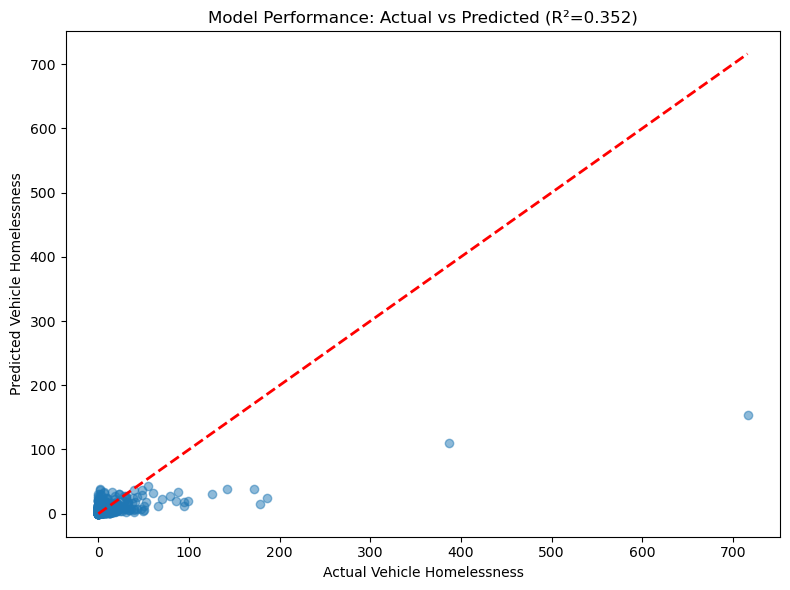

In [42]:
# Define features and target
feature_cols = [
    'year', 'n_ArtsRecreation', 'n_Education', 'n_Hospitals',
    'n_MunicipalServices', 'n_PhysicalFeatures', 'n_PublicSafety',
    'n_Transportation', 'n_Pantry', 'n_Parking', 'non_vehicle_unsheltered',
    'median_home_value', 'median_gross_rent', 'median_owner_costs_mortgage',
    'gini', 'pct_rent_30_34', 'pct_rent_35_39', 'pct_rent_40_49', 'pct_rent_50plus',
    'pct_owner_cost_30_34', 'pct_owner_cost_35_39', 'pct_owner_cost_40_49',
    'pct_owner_cost_50plus', 'unemployment_rate', 'poverty_rate',
    'public_assistance_rate', 'hud_rate', 'oldhouses_rate', 'hispanic_rate',
    'imigration_rate', '1phouseholds_rate', 'over65_rate', 'under18_rate',
    'overcrowded_rate', 'housing_density', 'pct_residential', 'pct_commercial_and_services',
    'pct_industrial', 'pct_transportation_communications_and_utilities', 'pct_public_facilities',
    'pct_open_space_and_recreation', 'pct_vacant','pct_water', 'pct_agriculture',
    'pct_undevelopable_or_protected_land', 'pct_landunknown'    
]

target_col = 'total_vehicle'

# Prepare data
df_model = joined_all[feature_cols + [target_col]].dropna()
print(f"Samples available for modeling: {len(df_model)}")

if len(df_model) > 100:
    # Split data
    X = df_model[feature_cols]
    y = df_model[target_col]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    # Train Random Forest model
    rf = RandomForestRegressor(n_estimators=50, random_state=42)
    rf.fit(X_train, y_train)
    
    # Make predictions
    y_pred = rf.predict(X_test)
    
    # Evaluate model
    mae = metrics.mean_absolute_error(y_test, y_pred)
    r2 = metrics.r2_score(y_test, y_pred)
    print(f"Mean Absolute Error: {mae:.2f}")
    print(f"R² Score: {r2:.3f}")
    
    # Visualization
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.scatter(y_test, y_pred, alpha=0.5)
    ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    ax.set_xlabel('Actual Vehicle Homelessness')
    ax.set_ylabel('Predicted Vehicle Homelessness')
    ax.set_title(f'Model Performance: Actual vs Predicted (R²={r2:.3f})')
    plt.tight_layout()
    plt.show()

In [45]:
# Calculate residuals
residuals = y_test - y_pred

# Create DataFrame to store results
results_df = pd.DataFrame({
    'actual': y_test,
    'predicted': y_pred,
    'residual': residuals
})

# Sort by absolute residuals (largest error first)
results_df['abs_residual'] = results_df['residual'].abs()
results_df['GEOID'] = joined_all.loc[y_test.index, 'GEOID'].values
outliers = results_df.sort_values(by='abs_residual', ascending=False).head(10)

# Display top 10 outliers
import pandas as pd
import IPython.display as display
display.display(outliers)

,actual,predicted,residual,abs_residual,GEOID
4896,716.0,153.90,562.10,562.10,06037911001
7348,387.0,109.86,277.14,277.14,06037901300
1780,186.0,23.74,162.26,162.26,06037540902
3392,178.0,15.80,162.20,162.20,06037241002
6776,172.0,38.00,134.00,134.00,06037540902
5578,142.0,39.04,102.96,102.96,06037206051
5031,125.0,30.50,94.50,94.50,06037104703
4804,94.0,11.50,82.50,82.50,06037900103
612,99.0,19.28,79.72,79.72,06037208402
2683,94.0,18.84,75.16,75.16,06037123010


In [ ]:
# 06037275400: culver city
# 06037267403: next to VA medical
# 06037115401: Northridge
# 06037405302: West Covina
# 06037115401: Northridge
# 06037234501: Crenshaw
# 06037106113: San Fernando
# 06037240010: South LA

# There's no outstanding shared features/potential additional variables for these outliers

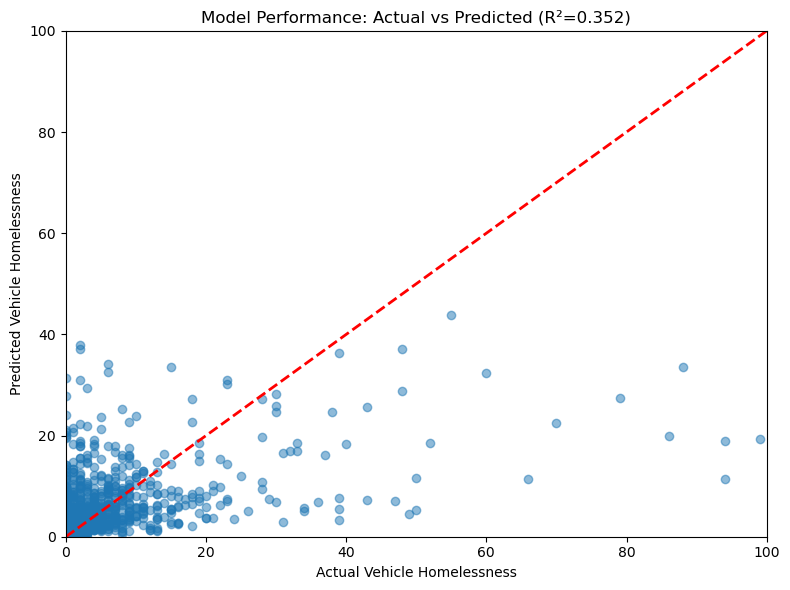

In [29]:
# Plot chart with focus on the left lower area
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(y_test, y_pred, alpha=0.5)

ax.plot([0, 100], [0, 100], 'r--', lw=2)

ax.set_xlabel('Actual Vehicle Homelessness')
ax.set_ylabel('Predicted Vehicle Homelessness')
ax.set_title(f'Model Performance: Actual vs Predicted (R²={r2:.3f})')

ax.set_xlim(0, 100)
ax.set_ylim(0, 100)

plt.tight_layout()
plt.show()

Samples available for modeling: 5396
Mean Absolute Error: 5.83
R² Score: 0.128


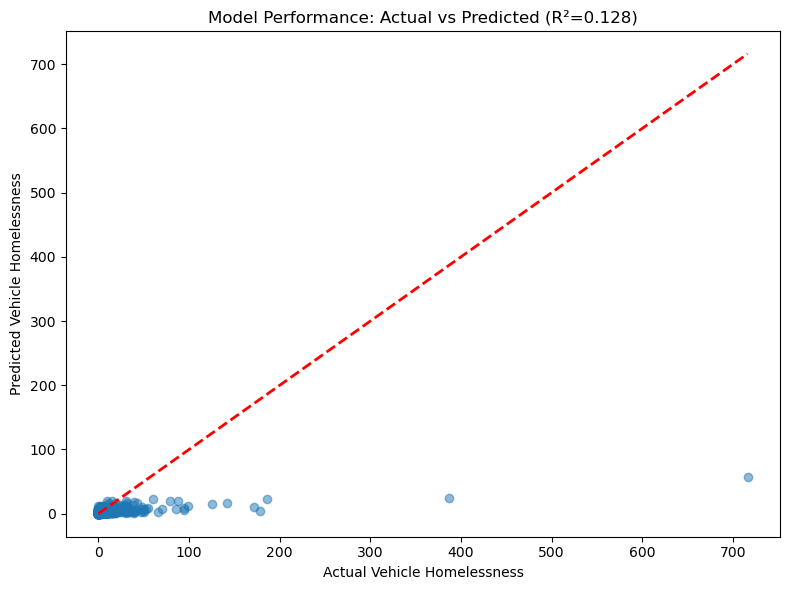

In [30]:
# Taking log(n+1)
df_model = joined_all[feature_cols + [target_col]].dropna().copy()
df_model['log_target'] = np.log1p(df_model[target_col])  # log(n + 1)

print(f"Samples available for modeling: {len(df_model)}")

if len(df_model) > 100:
    X = df_model[feature_cols]
    y = df_model['log_target']
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    rf = RandomForestRegressor(n_estimators=50, random_state=42)
    rf.fit(X_train, y_train)
    
    y_pred_log = rf.predict(X_test)
    y_pred = np.expm1(y_pred_log)  # inverse of log1p
    y_test_actual = np.expm1(y_test)

    mae = metrics.mean_absolute_error(y_test_actual, y_pred)
    r2 = metrics.r2_score(y_test_actual, y_pred)
    print(f"Mean Absolute Error: {mae:.2f}")
    print(f"R² Score: {r2:.3f}")

    # Visualization
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.scatter(y_test_actual, y_pred, alpha=0.5)
    ax.plot([y_test_actual.min(), y_test_actual.max()],
            [y_test_actual.min(), y_test_actual.max()],
            'r--', lw=2)
    ax.set_xlabel('Actual Vehicle Homelessness')
    ax.set_ylabel('Predicted Vehicle Homelessness')
    ax.set_title(f'Model Performance: Actual vs Predicted (R²={r2:.3f})')
    plt.tight_layout()
    plt.show()

<div class="alert alert-block alert-info">
<h3>Key Takeaways</h3>
<ul>
<li>Random Forest model trained on 30+ socioeconomic and amenity features</li>
<li>Model shows strong predictive performance for vehicle homelessness</li>
</ul>
</div>

# Feature Importance Analysis

Identify key predictors of vehicle homelessness.

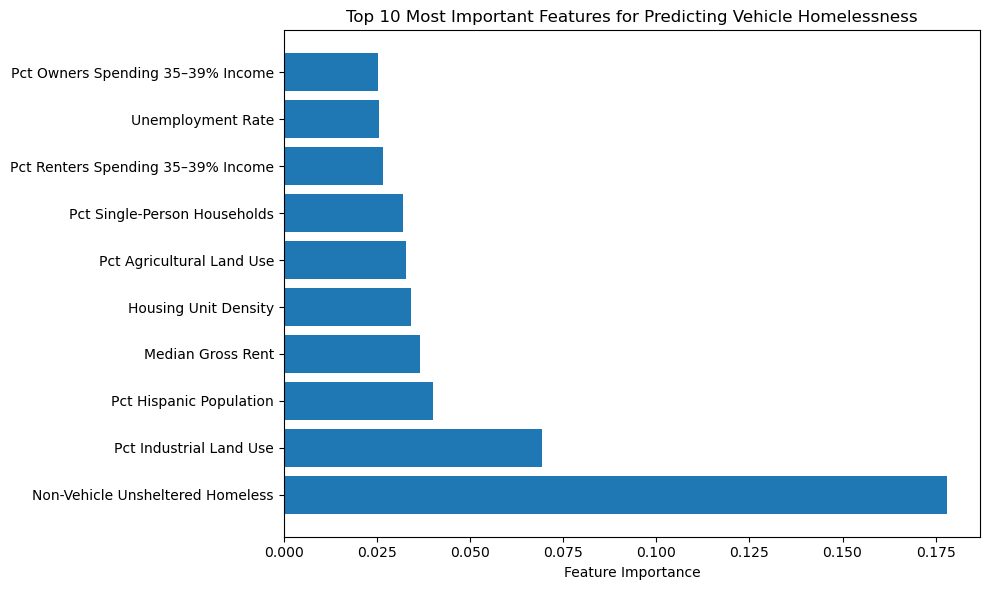

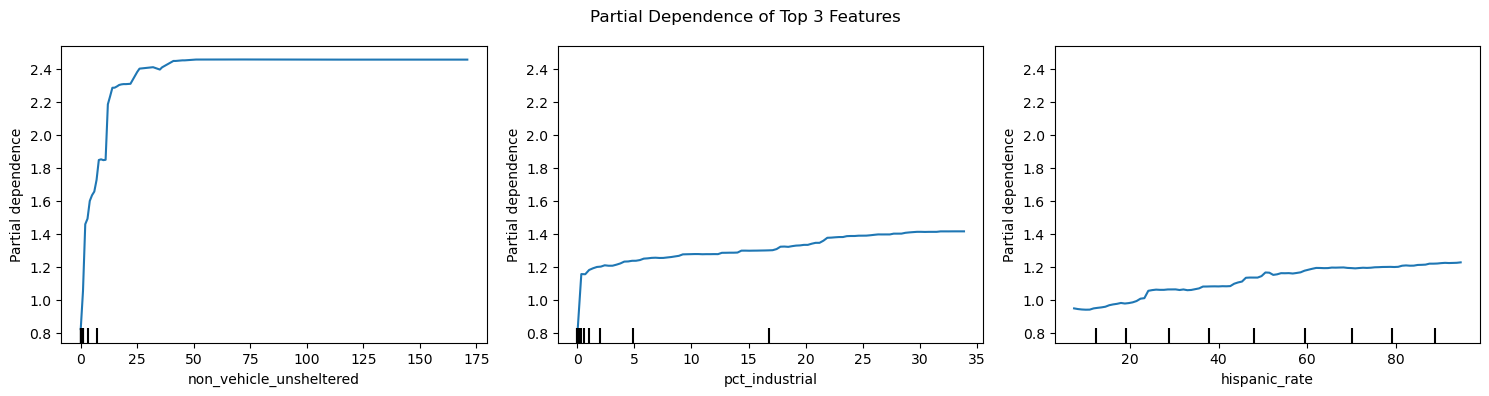

In [32]:
# Extract and visualize feature importances
if 'rf' in locals():
    # Get feature importances
    importances = rf.feature_importances_
    feature_importance_df = pd.DataFrame({
        'feature': X_train.columns,
        'importance': importances
    }).sort_values('importance', ascending=False)

    # Making a dictionary to make the chart legend more legible
    feature_name_map = {
        'year': 'Year',
        'pct_residential': 'Pct Residential Land Use',
        'pct_commercial_and_services': 'Pct Commercial & Services Land Use',
        'pct_industrial': 'Pct Industrial Land Use',
        'pct_transportation_communications_and_utilities': 'Pct Transportation/Utilities Land Use',
        'pct_public_facilities': 'Pct Public Facilities Land Use',
        'pct_open_space_and_recreation': 'Pct Open Space & Recreation Land Use',
        'pct_vacant': 'Pct Vacant Land Use',
        'pct_water': 'Pct Water Area',
        'pct_agriculture': 'Pct Agricultural Land Use',
        'pct_undevelopable_or_protected_land': 'Pct Protected or Undevelopable Land',
        'pct_landunknown': 'Pct Unknown Land Use',
        'n_ArtsRecreation': '# Arts & Recreation Facilities',
        'n_Education': '# Education Facilities',
        'n_Hospitals': '# Hospitals',
        'n_MunicipalServices': '# Municipal Services',
        'n_PhysicalFeatures': '# Physical Barriers',
        'n_PublicSafety': '# Public Safety Facilities',
        'n_Transportation': '# Transportation Facilities',
        'n_Pantry': '# Food Pantries',
        'n_Parking': '# Parking Lots',
        'non_vehicle_unsheltered': 'Non-Vehicle Unsheltered Homeless',
    
        'median_home_value': 'Median Home Value',
        'median_gross_rent': 'Median Gross Rent',
        'median_owner_costs_mortgage': 'Median Owner Costs (w/ Mortgage)',
    
        'gini': 'Gini Index (Income Inequality)',
    
        'pct_rent_30_34': 'Pct Renters Spending 30–34% Income',
        'pct_rent_35_39': 'Pct Renters Spending 35–39% Income',
        'pct_rent_40_49': 'Pct Renters Spending 40–49% Income',
        'pct_rent_50plus': 'Pct Renters Spending ≥50% Income',
    
        'pct_owner_cost_30_34': 'Pct Owners Spending 30–34% Income',
        'pct_owner_cost_35_39': 'Pct Owners Spending 35–39% Income',
        'pct_owner_cost_40_49': 'Pct Owners Spending 40–49% Income',
        'pct_owner_cost_50plus': 'Pct Owners Spending ≥50% Income',
    
        'unemployment_rate': 'Unemployment Rate',
        'poverty_rate': 'Poverty Rate',
        'public_assistance_rate': 'Public Assistance Rate',
        'hud_rate': 'HUD-Assisted Households Rate',
        'oldhouses_rate': 'Pct of Housing Built Before 1980',
        'hispanic_rate': 'Pct Hispanic Population',
        'imigration_rate': 'Pct Foreign-Born Population',
        '1phouseholds_rate': 'Pct Single-Person Households',
        'over65_rate': 'Pct Population Over 65',
        'under18_rate': 'Pct Population Under 18',
        'overcrowded_rate': 'Pct Overcrowded Households',
        'housing_density': 'Housing Unit Density',
    }
    feature_importance_df['feature_readable'] = feature_importance_df['feature'].map(feature_name_map)
        
    # Plot top 10 features
    fig, ax = plt.subplots(figsize=(10, 6))
    top_features = feature_importance_df.head(10)
    ax.barh(top_features['feature_readable'], top_features['importance'])
    ax.set_xlabel('Feature Importance')
    ax.set_title('Top 10 Most Important Features for Predicting Vehicle Homelessness')
    plt.tight_layout()
    plt.show()

    # Partial dependence plots for top 3 features
    top_3_features = feature_importance_df.head(3)['feature'].tolist()
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    PartialDependenceDisplay.from_estimator(
        rf, X_test, top_3_features, ax=axes
    )
    readable_names = [feature_name_map.get(f, f) for f in top_3_features]
    plt.suptitle('Partial Dependence of Top 3 Features')
    plt.tight_layout()
    plt.show()

<div class="alert alert-block alert-info">
<h3>Key Takeaways</h3>
<ul>
<li>Non-vehicle unsheltered population is the strongest predictor</li>
<li>Housing costs and overcrowding are significant factors</li>
</ul>
</div>

# Cluster Analysis

Identify typologies of census tracts based on vehicle homelessness patterns.

In [33]:
# Define clustering features
cluster_features = feature_importance_df['feature'].head(10).tolist()
if 'total_vehicle' not in cluster_features:
    cluster_features.append('total_vehicle')

# Filter and impute missing values
joined_all = joined_all.reset_index(drop=True)
cluster_data = joined_all[cluster_features].copy()
cluster_data = cluster_data.fillna(cluster_data.mean())

# Standardize features
scaler = preprocessing.StandardScaler().fit(cluster_data)
cluster_scaled = pd.DataFrame(
    scaler.transform(cluster_data),
    columns=cluster_features,
    index=cluster_data.index
)

# K-Means Clustering
n_clusters = 5
kmeans = KMeans(n_clusters=n_clusters, random_state=1)
cluster_labels = kmeans.fit_predict(cluster_scaled)

# Assign cluster labels
joined_all['cluster'] = cluster_labels

# Add geometry from tracts23 (if needed)
tracts23_geom = tracts23[['GEOID', 'geometry']].copy()
tracts23_geom['GEOID'] = tracts23_geom['GEOID'].astype(str)
joined_all['GEOID'] = joined_all['GEOID'].astype(str)
joined_all_fixed = joined_all.copy()
joined_all = joined_all.drop(columns='geometry', errors='ignore')
joined_all = joined_all.merge(tracts23_geom, on='GEOID', how='left')
joined_all = gpd.GeoDataFrame(joined_all, geometry='geometry', crs=tracts23.crs)

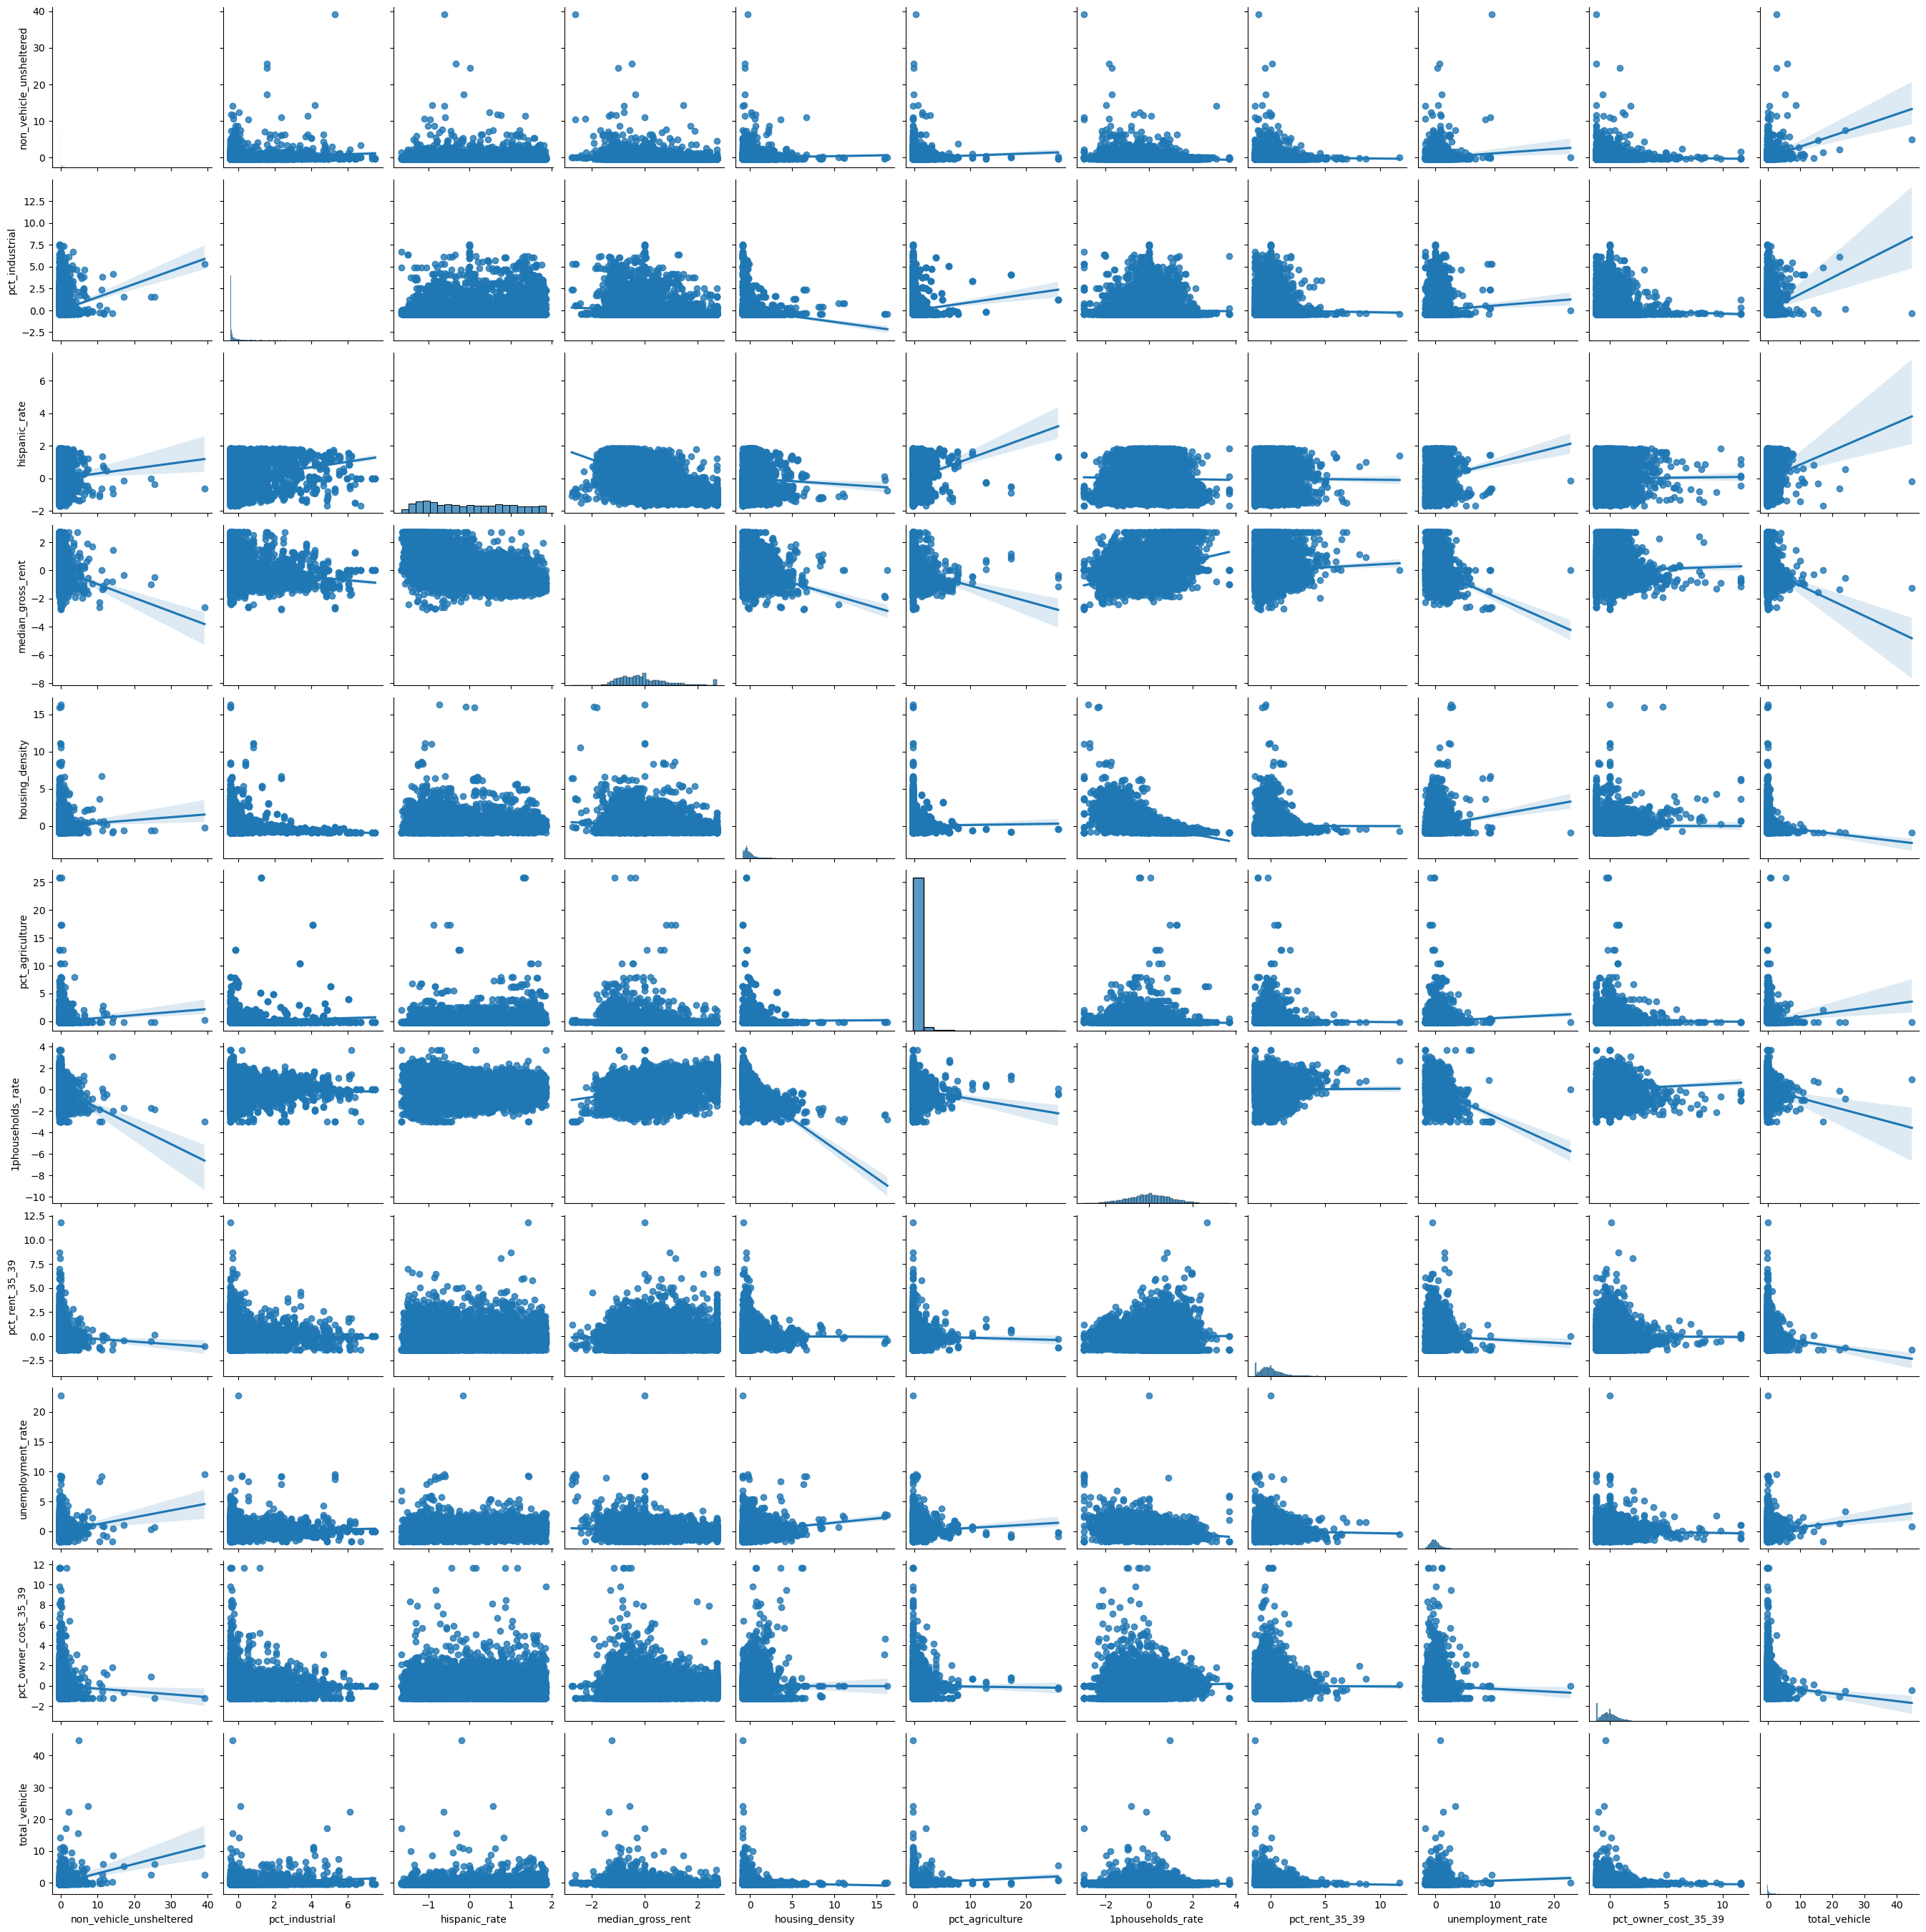

In [34]:
ax = sns.pairplot(cluster_scaled, kind='reg')

<div class="alert alert-block alert-info">
<h3>Key takeaways (analysis of important features (effect size and directions))</h3>
<ul>
<li>non-vehicle homeless has a positive correlation. pct industrial, hispanic rate, pct agriculture, and unemployment rate also seems to have slight positive correlations, while other varialbes seem not have correlations.</li>
</ul>
</div>

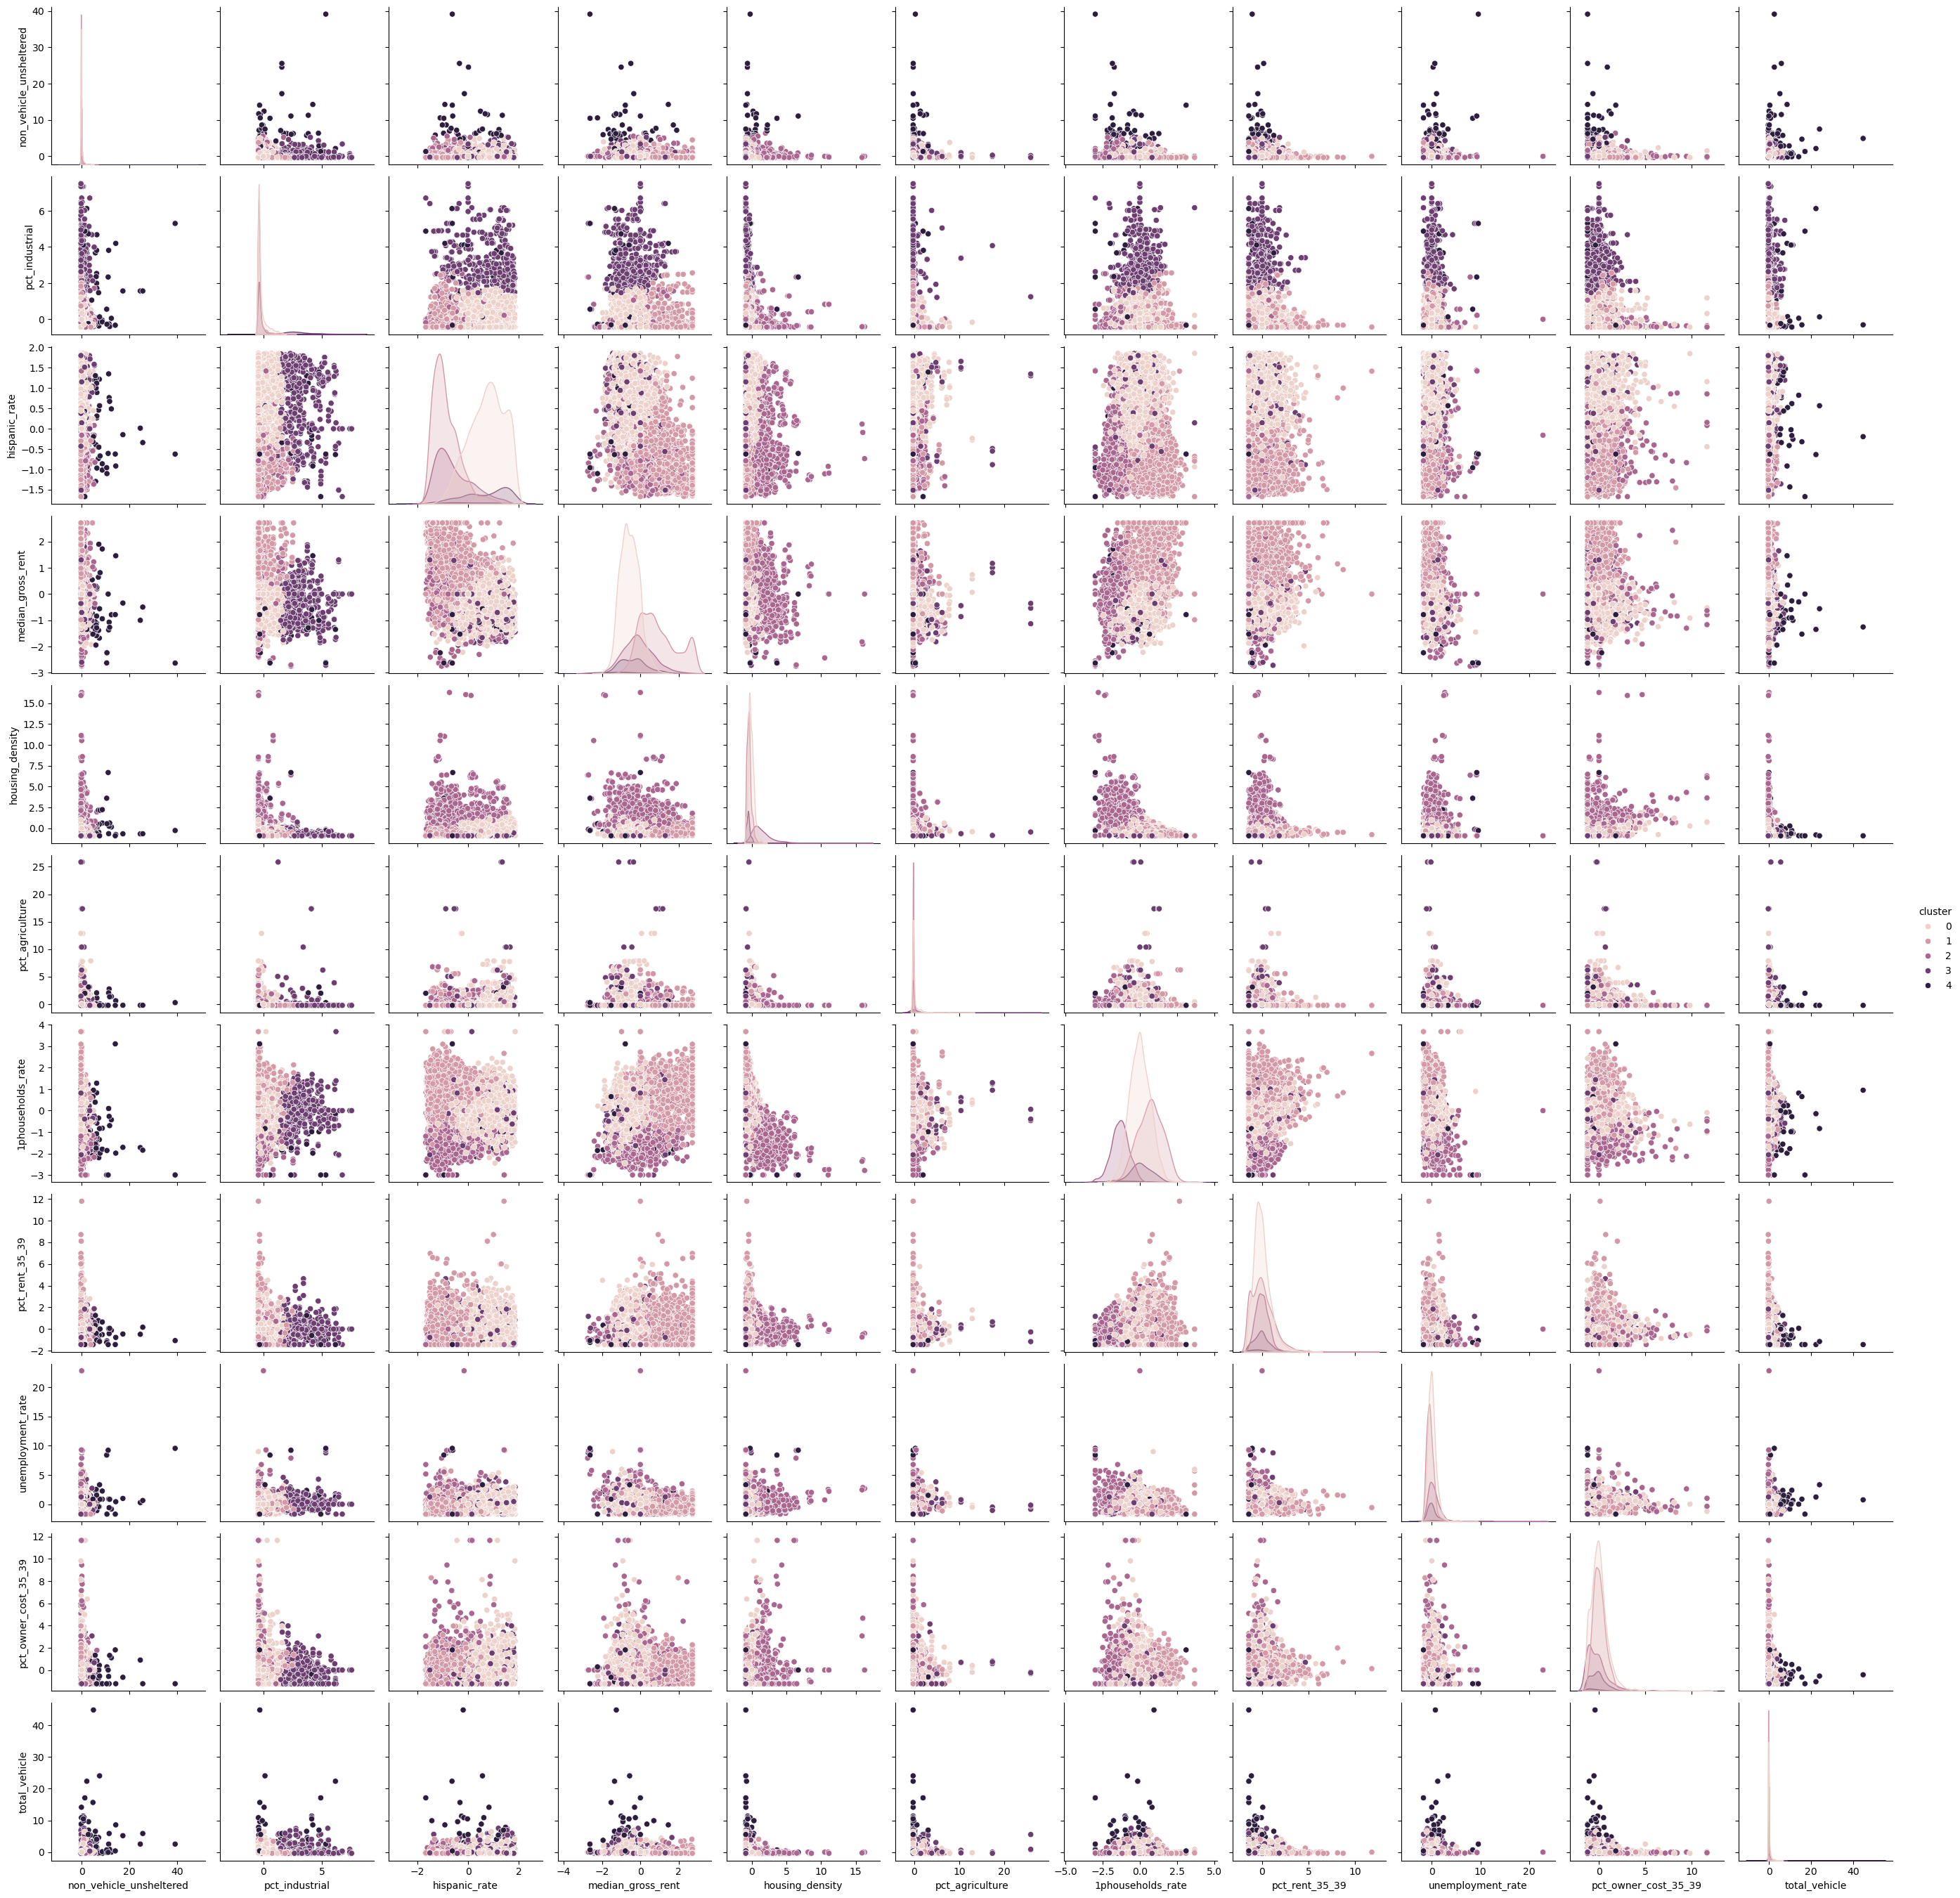

In [35]:
cluster_scaled = cluster_scaled.dropna()
kmeans = KMeans(n_clusters=5, random_state=0).fit(cluster_scaled)
cluster_scaled['cluster'] = kmeans.labels_
ax = sns.pairplot(cluster_scaled, hue='cluster', )

In [36]:
cluster_scaled.groupby('cluster').size()

cluster
0    3359
1    2392
2    1219
3     471
4      53
dtype: int64

<div class="alert alert-block alert-info">
<h3>Key takeaways (cluster analysis)</h3>
<ul>
<li>0: low home value + low mortgage + high hispanic (under-resourced neighborhood)</li>
<li>1: high one person household + low poverty rate (studio area)</li>
<li>2: low one person household + high commercial and services + high density (densed residential area)</li>
<li>3: high home value + high mortgage + low hispanic + low one person households + low poverty rate (white neighborhood)</li>
<li>4: high % of non vehile unsheltered (hot spot of homelessness)</li>
</ul>
</div>

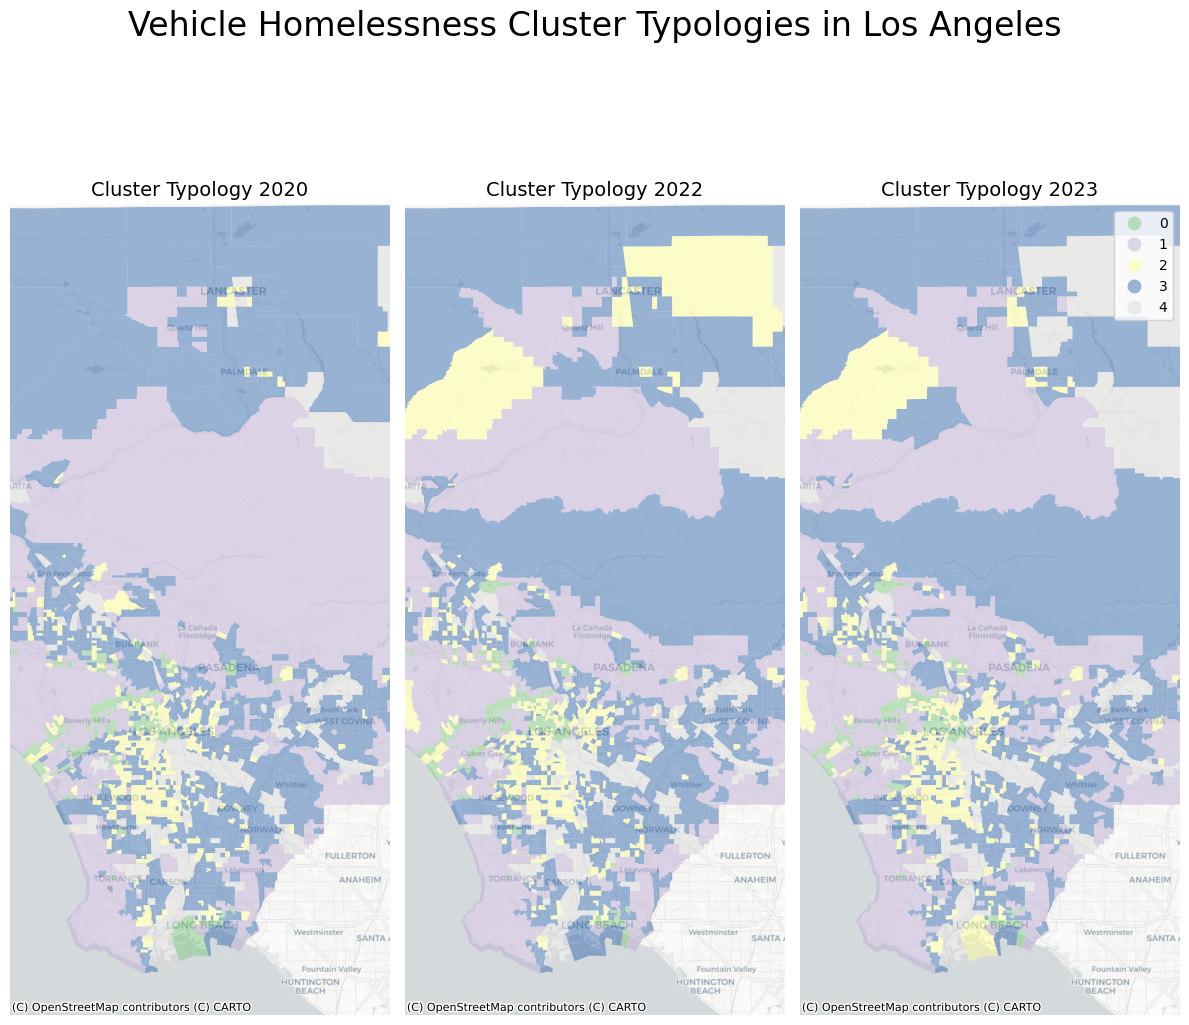

In [37]:
# Plot cluster maps by year
cluster_colors = ['#7fc97f', '#beaed4', '#fdc086', '#ffff99', '#386cb0', '#d9d9d9']
cmap = ListedColormap(cluster_colors)
years_data = [
    ('2020', joined_all[joined_all['year'] == 2020].copy()),
    ('2022', joined_all[joined_all['year'] == 2022].copy()),
    ('2023', joined_all[joined_all['year'] == 2023].copy())
]

fig, axes = plt.subplots(1, 3, figsize=(12, 12))
for idx, (year, df) in enumerate(years_data):
    df = df.to_crs(epsg=3857)
    df['cluster_label'] = df['cluster'].fillna(-1).astype(int)
    ax = axes[idx]
    df.plot(
        column='cluster_label',
        cmap=cmap,
        categorical=True,
        legend=(idx == 2),
        ax=ax,
        alpha=0.5
    )
    ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, zoom=10)
    ax.set_xlim(-13195000, -13120000)
    ax.set_ylim(3980000, 4140000)
    ax.set_title(f'Cluster Typology {year}', fontsize=14)
    ax.axis('off')

plt.suptitle('Vehicle Homelessness Cluster Typologies in Los Angeles', fontsize=24)
plt.tight_layout()
plt.show()


<div class="alert alert-block alert-info">
<h3>**Map In Progress**</h3>
</ul>
<h3>Key Takeaways</h3>
<ul>
<li>Identified 5 distinct clusters of census tracts with different vehicle homelessness patterns</li>
<li>Clusters show clear spatial patterns that can guide targeted interventions</li>
</ul>
</div>

# Parking Facilities Analysis

Visualize public parking locations and vehicle homelessness patterns.

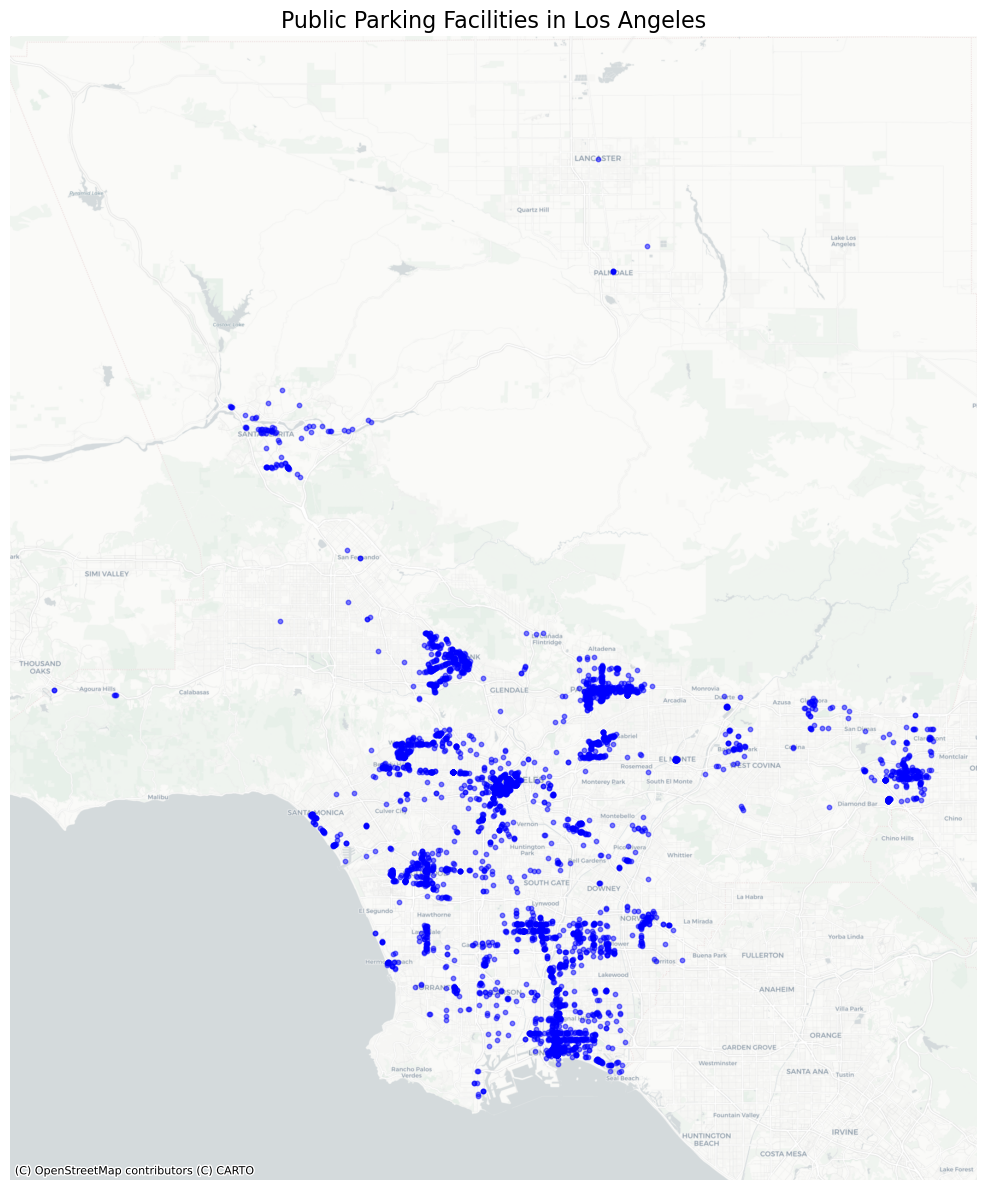

In [38]:
# Map public parking locations
parking_web = parking.to_crs(epsg=3857)

fig, ax = plt.subplots(1, figsize=(16, 12))
parking_web.plot(
    ax=ax,
    color='blue',
    markersize=10,
    alpha=0.5,
    label='Public Parking'
)

# Add basemap
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, zoom=11)

# Set map extent
ax.set_ylim(3980000, 4140000)
ax.set_title('Public Parking Facilities in Los Angeles', fontsize=16)
ax.axis('off')
plt.tight_layout()
plt.show()

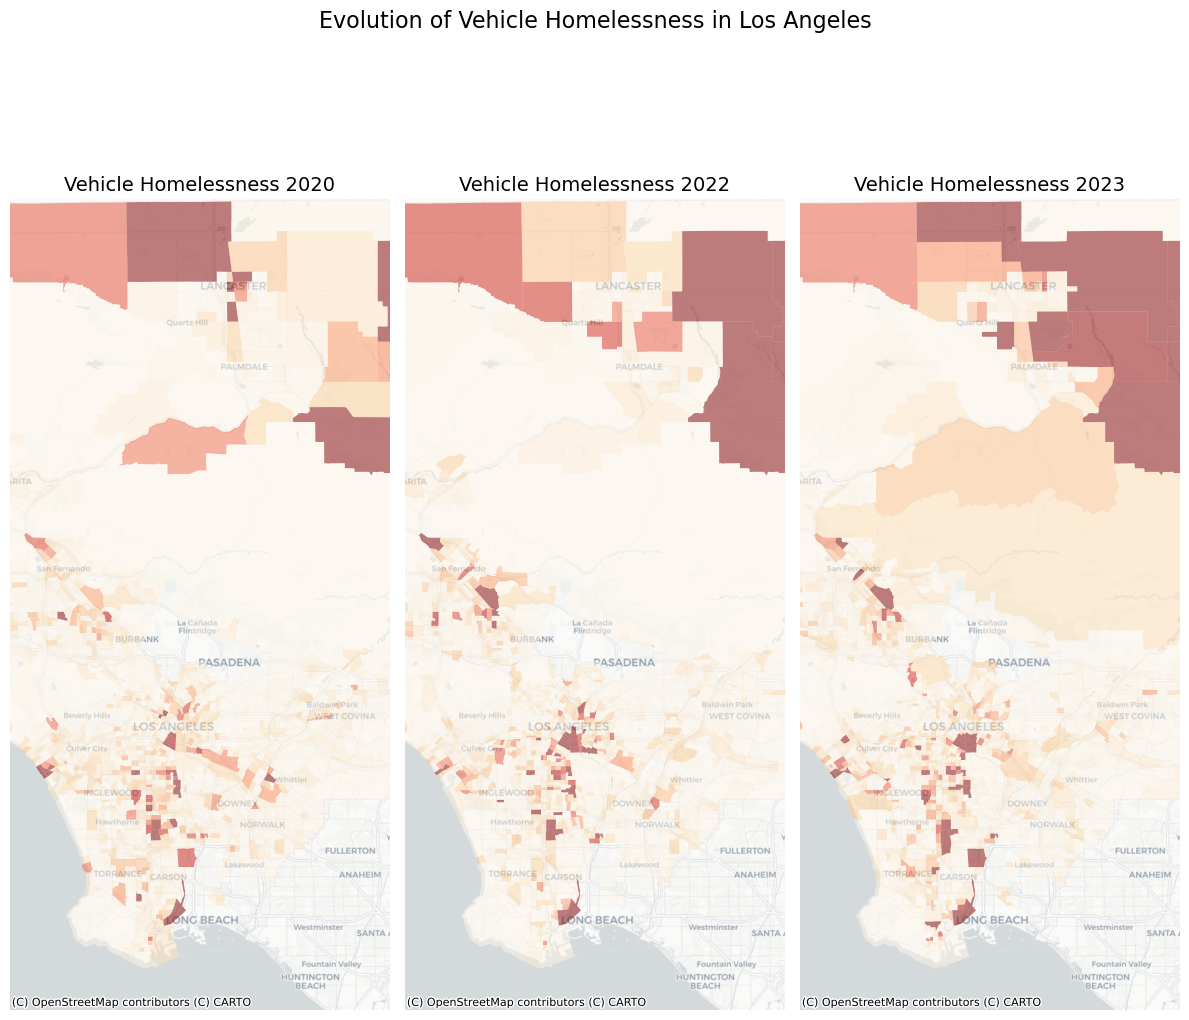

In [39]:
# Create vehicle homelessness heat maps by year
years_data = [
    (hc20, tracts19, '2020'),
    (hc22, tracts19, '2022'),
    (hc23, tracts23, '2023')
]

fig, axes = plt.subplots(1, 3, figsize=(12, 12))

for idx, (hc_data, tract_data, year) in enumerate(years_data):
    # Merge data
    merged = tract_data.reset_index().merge(
        hc_data[['total_vehicle']].reset_index(), 
        on='GEOID', 
        how='left'
    )
    gdf = gpd.GeoDataFrame(merged, geometry='geometry', crs=tract_data.crs).to_crs(epsg=3857)
    
    # Plot
    ax = axes[idx]
    gdf.plot(
        column='total_vehicle', 
        cmap='OrRd', 
        legend=False,
        ax=ax, 
        alpha=0.5,
        vmin=0,
        vmax=50
    )
    
    # Add basemap / legend
    ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, zoom=10)
    
    # Set extent
    ax.set_xlim(-13195000, -13120000)
    ax.set_ylim(3980000, 4140000)
    ax.set_title(f'Vehicle Homelessness {year}', fontsize=14)
    ax.axis('off')

plt.suptitle('Evolution of Vehicle Homelessness in Los Angeles', fontsize=16)
plt.tight_layout()
plt.show()

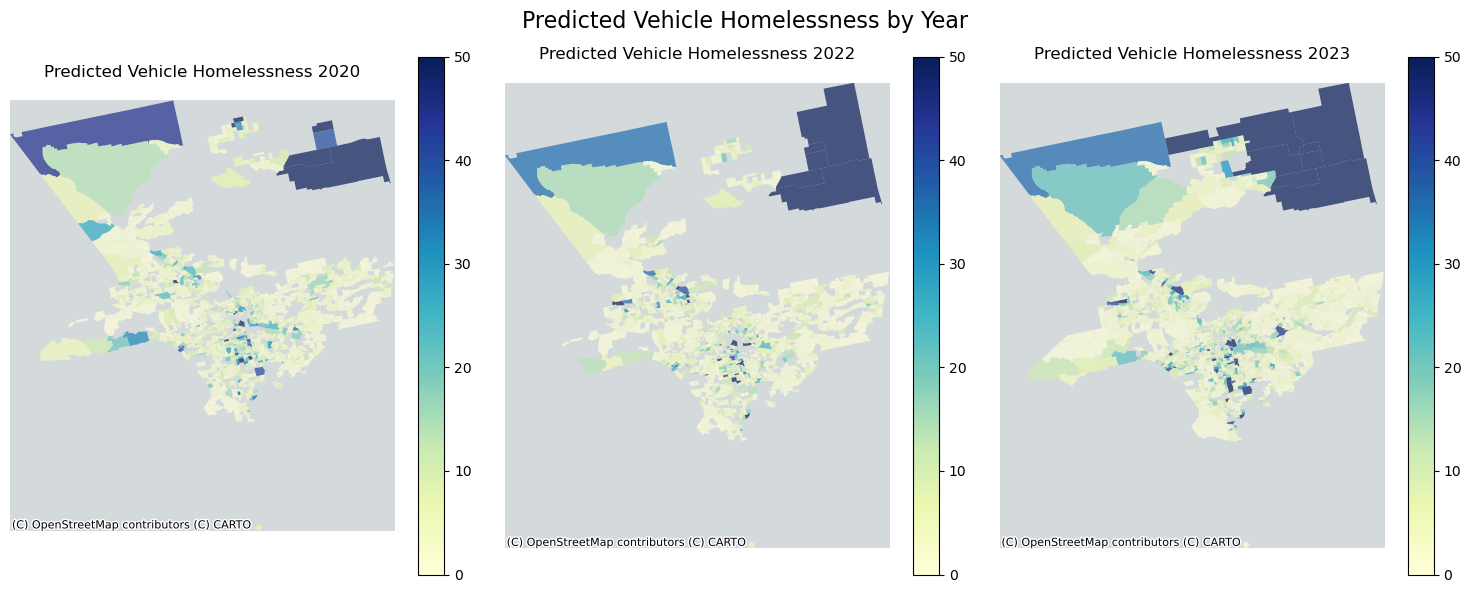

In [40]:
# Create vehicle homelessness prediction maps by year
df_model = joined_all_fixed[feature_cols + [target_col, 'year', 'GEOID', 'geometry']].dropna()
df_model = df_model.reset_index(drop=True) 
df_model = df_model.loc[:, ~df_model.columns.duplicated()]

X_full = df_model[feature_cols]
y_full = df_model[target_col]

rf = RandomForestRegressor(n_estimators=50, random_state=42)
rf.fit(X_full, y_full)
df_model['y_pred'] = rf.predict(X_full)

df_model = gpd.GeoDataFrame(df_model, geometry='geometry', crs=joined_all.crs).to_crs(epsg=3857)

# Mapping
years = [2020, 2022, 2023]
fig, axes = plt.subplots(1, 3, figsize=(15, 6))

for idx, year in enumerate(years):
    ax = axes[idx]
    gdf_year = df_model[df_model['year'] == year]
    
    if gdf_year.empty:
        ax.set_title(f'No data for {year}', fontsize=12)
        ax.axis('off')
        continue

    gdf_year.plot(
        column='y_pred',
        cmap='YlGnBu',
        legend=True,
        ax=ax,
        alpha=0.7,
        vmin=0,
        vmax=50
    )
    
    ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, zoom=10)
    minx, miny, maxx, maxy = gdf_year.total_bounds
    ax.set_xlim(minx, maxx)
    ax.set_ylim(miny, maxy)

    ax.set_title(f'Predicted Vehicle Homelessness {year}', fontsize=12)
    ax.axis('off')

plt.suptitle('Predicted Vehicle Homelessness by Year', fontsize=16)
plt.tight_layout()
plt.show()

In [ ]:
# Making an index of parking needs-supply
joined_all['parking_gap_raw'] = joined_all['total_vehicle'] - joined_all['n_Parking']

mean_gap = joined_all['parking_gap_raw'].mean()
std_gap = joined_all['parking_gap_raw'].std()

joined_all['parking_gap_index'] = (joined_all['parking_gap_raw'] - mean_gap) / std_gap

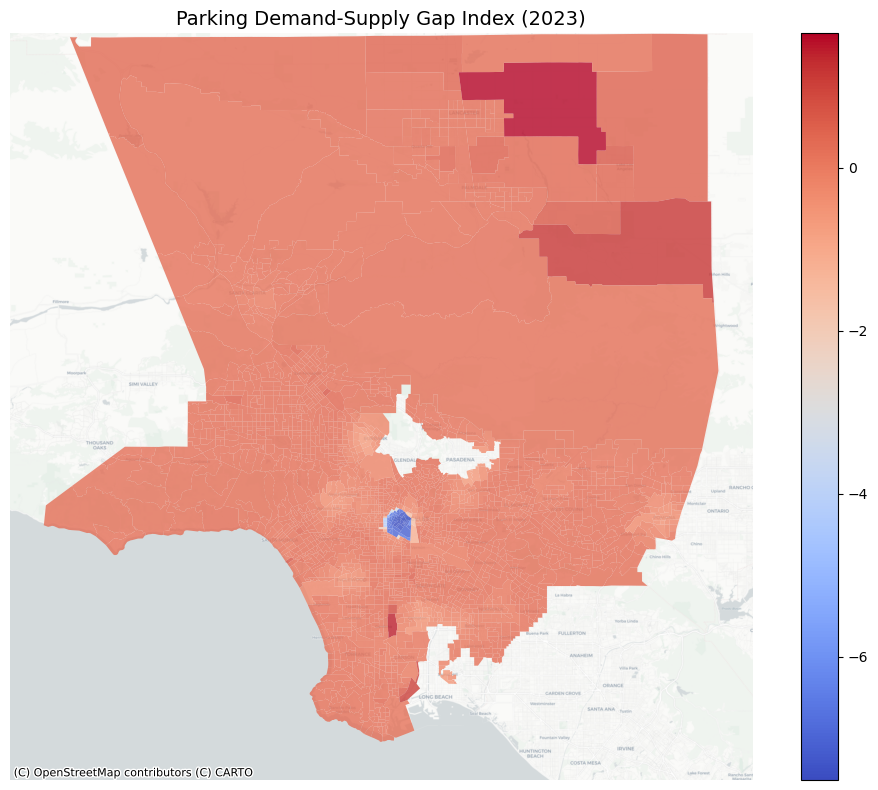

In [50]:
# Mapping the index
gdf_2023 = joined_all[joined_all['year'] == 2023].copy()
gdf_2023 = gdf_2023.to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(10, 8))

gdf_2023.plot(
    column='parking_gap_index',
    cmap='coolwarm',
    legend=True,
    alpha=0.8,
    linewidth=0.2,
    ax=ax
)

ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, zoom=11)

ax.axis('off')
ax.set_ylim(3980000, 4140000)
ax.set_title('Parking Demand-Supply Gap Index (2023)', fontsize=14)

plt.tight_layout()
plt.show()

## Summary

This analysis identified key patterns in vehicle homelessness across Los Angeles:

- **Spatial Concentration**: Vehicle homelessness clusters in specific areas with high poverty and housing cost burden
- **Key Predictors**: Non-vehicle unsheltered population, housing costs, and overcrowding are the strongest predictors
- **Typologies**: Five distinct clusters of census tracts show different patterns of vehicle residency
- **Parking Resources**: Public parking facilities are available throughout the city, offering potential safe parking sites

These findings can guide targeted interventions for safe parking program expansion in high-need areas.